# Graph Neural Networks

In this notebook we will look at some task that use *graph neural network* (a *GNN*) for node classification and graph classification.

Using knowledge from the first day, we could manually construct our own message-passing GNN architecture, out of the building blocks from `torch.nn`. Instead however, we will be using the [PyTorch Geometric](https://pytorch-geometric.readthedocs.io/en/latest/index.html) package to do a lot of the things without too namy lines of code.

In [6]:
#imports
import random
import itertools
import functools
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse.csgraph

import networkx as nx

import torch
import torch.nn as nn
import torch_geometric
from torch_geometric.data import Data
from torch_geometric.utils import from_networkx
from itertools import combinations
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader


# Node classification, Task 0: easy degree classifier:

Task — predict node degree class on a random graph
Label each node by a discretised version of its degree:
$$y_v = \begin{cases} 0 & \deg(v) \leq 3 \\ 1 & 4 \leq \deg(v) \leq 5 \\ 2 & \deg(v) > 6 \end{cases}$$
This is a task a GNN should ace — degree is purely local information, detectable in a single hop.

## Creating dataset

Here we make a dataset of random [Erdős–Rényi](https://en.wikipedia.org/wiki/Erd%C5%91s%E2%80%93R%C3%A9nyi_model) graphs: for every two vertices we add an edge between them with probability $p$.

For a faster learning, it is better if the nodes with different labels (0,1,2) appear more or less equally offten. It is not so easy for this task, so we apply corresponding weights to balance this difference during the training stage.

In [7]:
# --- Dataset ---
#Just computes the label corresponding to the degree
def degree_class(d):
        if d <= 3:   return 0   # low degree
        elif d <= 6: return 1   # medium
        else:        return 2   # high

#Make a graph and convert it to the dataset that torch can understand using `from_networks`
def make_degree_graph(n=40, p=0.12):
    G = nx.erdos_renyi_graph(n=n, p=p)
    while not nx.is_connected(G): #not necessary but it is nicer when all G are connected
        G = nx.erdos_renyi_graph(n=n, p=p)

    # Expected degree ~ (n-1)*p
    # Rebalance thresholds to get roughly equal classes
    

    labels = [degree_class(G.degree(v)) for v in G.nodes()]
    
    data = from_networkx(G)
    data.x = torch.ones(G.number_of_nodes(), 1)
    # Instead of degree features we could assign random features:
    #data.x = torch.rand(data.num_nodes, 1) # here the second argument is the dimesion of features
    data.y = torch.tensor(labels, dtype=torch.long)
    return data

# Check class balance before training
sample = make_degree_graph()
counts = sample.y.bincount()
print(f"Class counts in one graph: {counts.tolist()}")



Class counts in one graph: [6, 22, 12]


In [8]:
# Build a dataset of 300 graphs
dataset    = [make_degree_graph() for _ in range(300)]

#Split the data-set into training and testing parts
train_data = dataset[:240]
test_data  = dataset[240:]

#DataLoader ogranises the data sets into batches that later are used for training
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32)




In [9]:
#dimention of node features
DIM_IN = train_data[0].x.shape[1]

## Building a GNN
First step in building a GNN is to define what **message passing** we are going to use. As explained in the [PyTorch Geometric tutorial](https://pytorch-geometric.readthedocs.io/en/1.3.2/notes/create_gnn.html), the `torch_geometric.nn.MessagePassing` base class can set up a lot of the message-passing parameters: we only need to define an initialiser, a `message()` function (sends information from vertices to other vertices), an `aggr` method for aggregation of that information (`add`, `mean`, `max`, ...), and an `update()` function specifying what to do with that aggregated data. For us, both the `message()` and `update()` functions are the identity, and can be omitted from the class definition.

Alternatively, we could use pre-made message passings such as `GCNConv` -- they use self-looping approach as well as a special kind of normalisation:
$$h_v^{(k)}​=W^{(k)}\cdot \sum_{u\in \mathcal{N}(v)\cup\{v\}} \frac{​h_u^{(k−1)}}{​\sqrt{deg(u)deg(v)}}$$

In [11]:
# a custom GNN Layer
class GNNLayer(torch_geometric.nn.MessagePassing):
    def __init__(self, in_features, out_features):
        super().__init__(aggr='add') #choosing a sum as aggregation

        self.linear = nn.Linear(in_features, out_features) # Linear, not affine!

    def forward(self, x, edge_index):
        # x has shape [number_of_nodes, in_channels]
        # edge_index has shape [2, number_of_edges]

        # Add self-loops to the adjacency matrix.
        edge_index, _ = torch_geometric.utils.add_self_loops(edge_index, num_nodes=x.shape[0])

        # Transform features using the learnable parameters
        x = self.linear(x)

        # Propagate messages to other vertices.
        return self.propagate(edge_index, size=(x.shape[0], x.shape[0]), x=x)


# An example of how to run this layer: let's take a random graph from our dataset.
graph = dataset[0]

# graph.edge_index has shape [2, number_of_edges] and is an adjacency list. This gets
# passed to the GNN layer, along with a data tensor of shape [number_of_nodes, number_of_features].
# Note: the edge index defines the number of vertices in the graph only if you already know the graph
# is connected.
#
# Here we are simulating a layer which maps a DIM_IN-feature vector sitting over each vertex to a 3-feature
# vector sitting over each vertex.
# Input features: shape [# vertices, # features]
GNNLayer(DIM_IN, 3)(torch.zeros(40, DIM_IN), graph.edge_index)

tensor([[ 3.7130,  0.9232, -1.5640],
        [ 2.3206,  0.5770, -0.9775],
        [ 5.1054,  1.2694, -2.1505],
        [ 3.7130,  0.9232, -1.5640],
        [ 2.7848,  0.6924, -1.1730],
        [ 2.3206,  0.5770, -0.9775],
        [ 1.8565,  0.4616, -0.7820],
        [ 2.3206,  0.5770, -0.9775],
        [ 3.2489,  0.8078, -1.3685],
        [ 1.8565,  0.4616, -0.7820],
        [ 2.7848,  0.6924, -1.1730],
        [ 1.8565,  0.4616, -0.7820],
        [ 1.3924,  0.3462, -0.5865],
        [ 0.9283,  0.2308, -0.3910],
        [ 1.3924,  0.3462, -0.5865],
        [ 2.3206,  0.5770, -0.9775],
        [ 2.7848,  0.6924, -1.1730],
        [ 3.2489,  0.8078, -1.3685],
        [ 1.3924,  0.3462, -0.5865],
        [ 2.7848,  0.6924, -1.1730],
        [ 5.1054,  1.2694, -2.1505],
        [ 2.3206,  0.5770, -0.9775],
        [ 3.2489,  0.8078, -1.3685],
        [ 1.8565,  0.4616, -0.7820],
        [ 3.2489,  0.8078, -1.3685],
        [ 2.7848,  0.6924, -1.1730],
        [ 3.7130,  0.9232, -1.5640],
 

In [12]:
# Or just use ready message passing
GCNConv(DIM_IN, 3)(torch.zeros(40, DIM_IN), graph.edge_index)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], grad_fn=<AddBackward0>)

Now we are ready to construct our GNN. We just need to specify dimentions of hidden layers, classifier and nonlinearity in message passing.

In [22]:
# --- Model ---
class DegreeGNN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        #self.conv1 = GNNLayer(1,  32)
        #self.conv2 = GNNLayer(32, 32)
        self.conv1 = GCNConv(1,  32)  #alternatively use  GCN layer
        self.conv2 = GCNConv(32, 32)
        # Node-level classifier: hidden_dim -> 3 classes 
        self.classifier = torch.nn.Linear(32, 3)  # 3 degree classes

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Two rounds of message passing
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)

        # f: learned linear classifier on each node's representation
        return self.classifier(x) # shape [num_nodes, 3]



In [23]:

# --- Training ---
model     = DegreeGNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

# Compute class weights to counteract imbalance
all_labels = torch.cat([d.y for d in train_data])
counts     = all_labels.bincount().float()
weights    = 1.0 / counts
weights    = weights / weights.sum()
print(f"Class distribution: {counts.tolist()}")
print(f"Class weights:      {weights.tolist()}")

# Use weighted loss
#def train():
#model.train()
#    for batch in train_loader:
#        optimizer.zero_grad()
#        loss = F.cross_entropy(model(batch), batch.y, weight=weights)
#        loss.backward()
#        optimizer.step()

def train():
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        loss = F.cross_entropy(model(batch), batch.y)
        loss.backward()
        optimizer.step()

@torch.no_grad()
def accuracy(loader):
    model.eval()
    correct = total = 0
    for batch in loader:
        correct += (model(batch).argmax(dim=1) == batch.y).sum().item()
        total   += batch.y.size(0)
    return correct / total



Class distribution: [2710.0, 5112.0, 1778.0]
Class weights:      [0.32740622758865356, 0.1735662817955017, 0.4990275204181671]


In [24]:


for epoch in range(1, 401):
    train()
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | "
              f"Train {accuracy(train_loader):.3f} | "
              f"Test {accuracy(test_loader):.3f}")

Epoch  50 | Train 0.878 | Test 0.874
Epoch 100 | Train 0.879 | Test 0.875
Epoch 150 | Train 0.880 | Test 0.872
Epoch 200 | Train 0.874 | Test 0.871
Epoch 250 | Train 0.881 | Test 0.877
Epoch 300 | Train 0.883 | Test 0.880
Epoch 350 | Train 0.833 | Test 0.834
Epoch 400 | Train 0.868 | Test 0.865


## Questions
1. Train two different models, using our custume Layers and GCNConv respectively. Which one performs better? Any idea why?
2. Play with the number of layers. Is a single layer eough?

The two cells below contain the function `predit_degrees` which you can use to apply the trained model to a single graph and see how it performs; and `draw_degree_predictions` which will allow you to SEE how it performs. 

In [25]:
def predict_degrees(model, G):
    model.eval()
    
    data = from_networkx(G)
    data.x = torch.ones(G.number_of_nodes(), 1)

    with torch.no_grad():
        logits = model(data)
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)

    return preds, probs

# --- New graph ---
G_new = nx.erdos_renyi_graph(n=40, p=0.12)
while not nx.is_connected(G_new):
    G_new = nx.erdos_renyi_graph(n=40, p=0.12)

preds, probs = predict_degrees(model, G_new)

# Compare prediction vs ground truth for each node
median = int(np.median([G_new.degree(v) for v in G_new.nodes()]))
print(f"Median degree: {median}\n")
print(f"{'Node':>4} | {'Degree':>6} | {'True':>4} | {'Pred':>4} | Correct?")
print("-" * 40)
for v in G_new.nodes():
    d    = G_new.degree(v)
    true = degree_class(G_new.degree(v))
    pred = preds[v].item()
    ok   = "✓" if true == pred else "✗"
    print(f"{v:>4} | {d:>6} | {true:>4} | {pred:>4} | {ok}")

Median degree: 4

Node | Degree | True | Pred | Correct?
----------------------------------------
   0 |      6 |    1 |    2 | ✗
   1 |      5 |    1 |    1 | ✓
   2 |      2 |    0 |    0 | ✓
   3 |      5 |    1 |    1 | ✓
   4 |      4 |    1 |    1 | ✓
   5 |      1 |    0 |    0 | ✓
   6 |      2 |    0 |    0 | ✓
   7 |      5 |    1 |    1 | ✓
   8 |      5 |    1 |    1 | ✓
   9 |      5 |    1 |    1 | ✓
  10 |      5 |    1 |    1 | ✓
  11 |      4 |    1 |    1 | ✓
  12 |      3 |    0 |    1 | ✗
  13 |      4 |    1 |    1 | ✓
  14 |      3 |    0 |    1 | ✗
  15 |      4 |    1 |    1 | ✓
  16 |      9 |    2 |    2 | ✓
  17 |      5 |    1 |    1 | ✓
  18 |      1 |    0 |    0 | ✓
  19 |      2 |    0 |    0 | ✓
  20 |      3 |    0 |    1 | ✗
  21 |      3 |    0 |    1 | ✗
  22 |      3 |    0 |    1 | ✗
  23 |      2 |    0 |    0 | ✓
  24 |      3 |    0 |    1 | ✗
  25 |      3 |    0 |    1 | ✗
  26 |      3 |    0 |    1 | ✗
  27 |      2 |    0 |    0 | ✓
  28 |

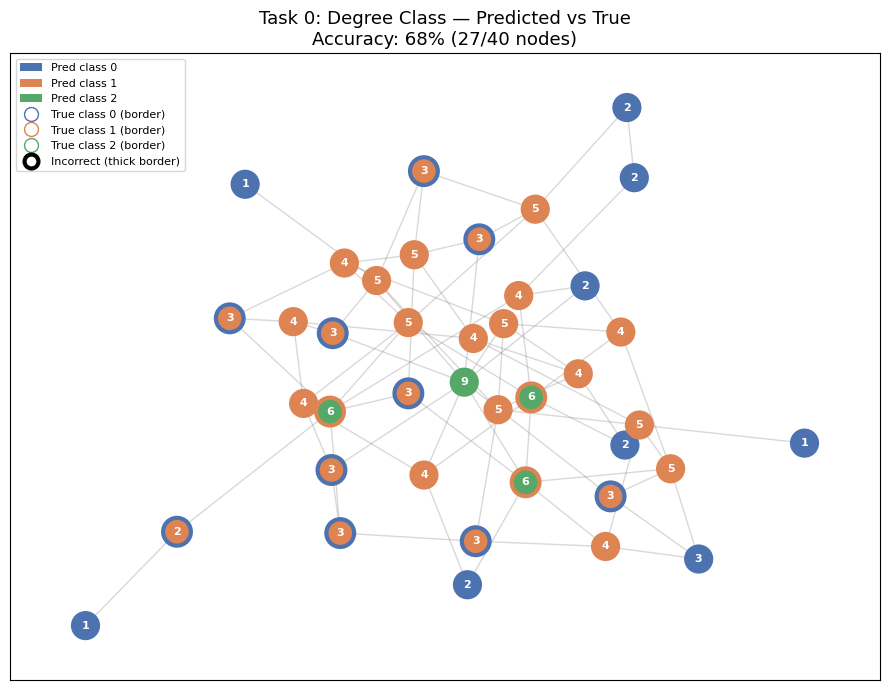

In [26]:
def draw_degree_predictions(G, preds, title='Task 0: Degree Class — Predicted vs True'):
    """
    Draw G with nodes coloured by predicted label (fill) and
    bordered by true label colour.  A legend explains both.

    Degree classes  0 = low (deg ≤ 3)  1 = medium (4-6)  2 = high (> 6)
    """
    true_labels = [degree_class(G.degree(v)) for v in G.nodes()]
    pred_labels = [preds[v].item() for v in G.nodes()]

    # Colour palette for degree classes
    palette = {0: '#4C72B0', 1: '#DD8452', 2: '#55A868'}   # blue / orange / green
    node_color  = [palette[p] for p in pred_labels]        # fill  = predicted
    edgecolors  = [palette[t] for t in true_labels]        # border = true
    correct     = [p == t for p, t in zip(pred_labels, true_labels)]
    linewidths  = [3.0 if not c else 1.0 for c in correct]  # thicker border when wrong

    pos = nx.spring_layout(G, seed=42)

    fig, ax = plt.subplots(figsize=(9, 7))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.3, edge_color='grey')
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=node_color,
        edgecolors=edgecolors,
        linewidths=linewidths,
        node_size=400,
    )
    # Node labels: show degree
    degree_labels = {v: str(G.degree(v)) for v in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=degree_labels, ax=ax,
                            font_size=8, font_color='white', font_weight='bold')

    # Accuracy annotation
    acc = sum(correct) / len(correct)
    ax.set_title(f'{title}\nAccuracy: {acc:.0%} ({sum(correct)}/{len(correct)} nodes)',
                 fontsize=13)

    # Legend — fill colour = predicted class
    from matplotlib.patches import Patch
    import matplotlib.lines as mlines
    legend_pred  = [Patch(facecolor=palette[c], label=f'Pred class {c}') for c in range(3)]
    legend_true  = [mlines.Line2D([], [], color=palette[c], marker='o', markersize=10,
                                  markerfacecolor='none', linewidth=0,
                                  label=f'True class {c} (border)') for c in range(3)]
    legend_wrong = [mlines.Line2D([], [], color='black', marker='o', markersize=10,
                                  markerfacecolor='none', linewidth=0,
                                  markeredgewidth=3, label='Incorrect (thick border)')]
    ax.legend(handles=legend_pred + legend_true + legend_wrong,
              loc='upper left', fontsize=8, framealpha=0.8)
    plt.tight_layout()
    plt.show()


draw_degree_predictions(G_new, preds)

# Node classification, Task 1: maximum independent set membership 
Given a random graph $G$, label each node $v$ with:
$$
\begin{cases} 1 & v \text{ belongs to a maximum independent set} \\ 0 & \text{otherwise} \end{cases}
$$
**A maximum independent set (MIS)** is the largest subset of nodes with no two adjacent - so the label captures a hard combinatorial property of each node's role in the graph. This is NP-hard in general, but on small random graphs you can compute it exactly to build the training set.

First, let us prepare functions that will help us to generate the training data:

In [27]:
# function that tests if a set of nodes is indipendant
def is_independent_set(G, nodes):
    for u, v in combinations(nodes, 2):
        if G.has_edge(u, v):
            return False
    return True

def maximum_independent_set(G):
    """
    Compute a maximum independent set via brute force.
    Only feasible for small graphs (n <= ~20).
    """
    nodes = list(G.nodes())
    best = []
    # iterate over subsets in decreasing size
    for r in range(len(nodes), 0, -1):
        for subset in combinations(nodes, r):
            if is_independent_set(G, subset):
                best = list(subset)
                return best  # first found is maximum
    return best



def make_mis_graph(n=15, p=0.3):
    """
    Generate one Erdos-Renyi graph and label nodes by MIS membership.
    Node features: degree (1-dimensional).
    """
    G = nx.erdos_renyi_graph(n=n, p=p, seed=np.random.randint(1000))
    
    # Ensure graph is connected (optional but cleaner for our tasks)
    while not nx.is_connected(G):
        G = nx.erdos_renyi_graph(n=n, p=p, seed=np.random.randint(1000))
    
    mis = maximum_independent_set(G)
    labels = [1 if v in mis else 0 for v in G.nodes()]

    # Node features: normalised degree
    degrees = np.array([G.degree(v) for v in G.nodes()], dtype=np.float32)
    degrees = degrees / degrees.max()

    # Build PyG Data object
    data = from_networkx(G)
    data.x = torch.tensor(degrees, dtype=torch.float).unsqueeze(1)  # shape [n, 1]
    # Instead of degree features:
    # data.x = torch.rand(data.num_nodes, 4)  # 4-dimensional random features
    data.y = torch.tensor(labels, dtype=torch.long)
    return data



Notice that the function `make_mis_graph` above assings one dimentional features to the nodes (namely, the normalised degrees). There is a commented out option to assign random features of a given dimention.

Now lets generate the data:

In [28]:
# Build a dataset of 500 graphs
dataset = [make_mis_graph(n=8, p=0.3) for _ in range(500)]

# Train/test split
train_data = dataset[:400]
test_data  = dataset[400:]

print(f"Example graph: {train_data[0].num_nodes} nodes, "
      f"{train_data[0].num_edges} edges")
print(f"Labels: {train_data[0].y}") 
# e.g. tensor([0, 1, 0, 0, 1, ...])

Example graph: 8 nodes, 20 edges
Labels: tensor([1, 1, 0, 0, 1, 0, 1, 0])


In [29]:
dataset[0].edge_index


tensor([[0, 0, 0, 1, 2, 2, 3, 3, 3, 4, 4, 5, 5, 5, 6, 6, 6, 7, 7, 7],
        [3, 5, 7, 5, 4, 6, 0, 6, 7, 2, 5, 0, 1, 4, 2, 3, 7, 0, 3, 6]])

Let us remember the size of features, we need to know it for the GNN input size:

In [30]:
#dimention of node features
DIM_IN = train_data[0].x.shape[1]

In [39]:

class MIS_GNN(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.conv1 = GCNConv(DIM_IN, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        #self.conv1 = GNNLayer(1,  hidden_dim)
        #self.conv2 = GNNLayer(hidden_dim, hidden_dim)
        #self.conv3 = GCNConv(hidden_dim, hidden_dim)
        # Node-level classifier: hidden_dim -> 2 classes (in MIS / not in MIS)
        self.classifier = nn.Linear(hidden_dim, 2)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # Three rounds of message passing
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)

        # f: learned linear classifier on each node's representation
        return self.classifier(x)   # shape [num_nodes, 2]

In [40]:
# Training loop


train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32)

model     = MIS_GNN(hidden_dim=16)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_epoch():
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out  = model(batch)           # [total_nodes_in_batch, 2]
        loss = F.cross_entropy(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader)

@torch.no_grad()
def evaluate(loader):
    model.eval()
    correct = total = 0
    for batch in loader:
        pred = model(batch).argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total   += batch.y.size(0)
    return correct / total

In [51]:
for epoch in range(1, 501):
    loss = train_epoch()
    if epoch % 10 == 0:
        train_acc = evaluate(train_loader)
        test_acc  = evaluate(test_loader)
        print(f"Epoch {epoch:3d} | Loss {loss:.4f} | "
              f"Train {train_acc:.3f} | Test {test_acc:.3f}")

Epoch  10 | Loss 0.4203 | Train 0.799 | Test 0.791
Epoch  20 | Loss 0.4247 | Train 0.798 | Test 0.790
Epoch  30 | Loss 0.4218 | Train 0.795 | Test 0.785
Epoch  40 | Loss 0.4206 | Train 0.797 | Test 0.794
Epoch  50 | Loss 0.4243 | Train 0.797 | Test 0.794
Epoch  60 | Loss 0.4213 | Train 0.796 | Test 0.787
Epoch  70 | Loss 0.4228 | Train 0.792 | Test 0.789
Epoch  80 | Loss 0.4213 | Train 0.798 | Test 0.790
Epoch  90 | Loss 0.4245 | Train 0.794 | Test 0.791
Epoch 100 | Loss 0.4199 | Train 0.794 | Test 0.792
Epoch 110 | Loss 0.4200 | Train 0.803 | Test 0.795
Epoch 120 | Loss 0.4231 | Train 0.798 | Test 0.791
Epoch 130 | Loss 0.4240 | Train 0.801 | Test 0.791
Epoch 140 | Loss 0.4205 | Train 0.797 | Test 0.794
Epoch 150 | Loss 0.4240 | Train 0.793 | Test 0.791
Epoch 160 | Loss 0.4212 | Train 0.798 | Test 0.790
Epoch 170 | Loss 0.4246 | Train 0.798 | Test 0.790
Epoch 180 | Loss 0.4236 | Train 0.793 | Test 0.790
Epoch 190 | Loss 0.4223 | Train 0.794 | Test 0.791
Epoch 200 | Loss 0.4234 | Train

In [52]:
def predict_mis(model, G):
    """
    Run trained MIS_GNN on a new graph G.
    Returns predicted MIS node set and per-node probabilities.
    """
    model.eval()

    # Build PyG data object (same as training)
    data = from_networkx(G)
    degrees = torch.tensor(
        [G.degree(v) for v in G.nodes()], dtype=torch.float
    )
    data.x = (degrees / degrees.max()).unsqueeze(1)

    # Forward pass — no gradient needed
    with torch.no_grad():
        logits = model(data)                        # [n, 2]
        probs  = torch.softmax(logits, dim=1)[:, 1] # probability of being in MIS
        preds  = logits.argmax(dim=1)               # 0 or 1 per node

    predicted_mis = [v for v, p in enumerate(preds) if p == 1]
    return predicted_mis, probs

In [59]:
# --- Try it on a new graph ---
G_new = nx.erdos_renyi_graph(n=10, p=0.3) #, seed=42)
while not nx.is_connected(G_new):
    G_new = nx.erdos_renyi_graph(n=10, p=0.3, seed=np.random.randint(1000))

predicted_mis, probs = predict_mis(model, G_new)

# Ground truth for comparison
true_mis = maximum_independent_set(G_new)

print(f"Predicted MIS: {sorted(predicted_mis)}")
print(f"True MIS:      {sorted(true_mis)}")
print(f"Predicted is valid independent set: "
      f"{is_independent_set(G_new, predicted_mis)}")

# Per-node probabilities
for v in G_new.nodes():
    marker = " <-- predicted in MIS" if v in predicted_mis else ""
    print(f"  node {v:2d}: p={probs[v]:.3f}{marker}")

Predicted MIS: [1, 2, 3, 5]
True MIS:      [2, 3, 4, 5, 8]
Predicted is valid independent set: True
  node  0: p=0.106
  node  1: p=0.581 <-- predicted in MIS
  node  2: p=0.793 <-- predicted in MIS
  node  3: p=0.866 <-- predicted in MIS
  node  4: p=0.360
  node  5: p=0.854 <-- predicted in MIS
  node  6: p=0.018
  node  7: p=0.138
  node  8: p=0.458
  node  9: p=0.366


**Note:** while GNN might not predict "True" MIS, the one that `networkx` gives us, it may give a valid MIS, since it is not unique.

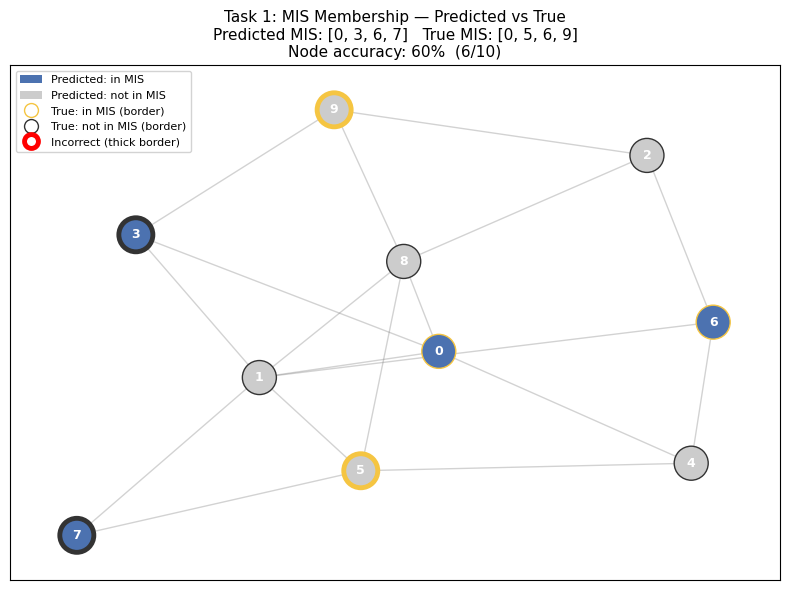

In [45]:
def draw_mis_predictions(G, predicted_mis, true_mis,
                         title='Task 1: MIS Membership — Predicted vs True'):
    """
    Draw G with a 2x2 colour scheme:
      Fill colour  → predicted label  (blue = in MIS, grey = not in MIS)
      Border colour→ true label       (gold = in MIS, black = not in MIS)
    Nodes with a mismatch get a thick border so errors are easy to spot.
    """
    pred_set = set(predicted_mis)
    true_set = set(true_mis)
    nodes = list(G.nodes())

    fill_color   = ['#4C72B0' if v in pred_set else '#CCCCCC' for v in nodes]  # blue / grey
    border_color = ['#F5C542' if v in true_set else '#333333' for v in nodes]  # gold / dark
    correct      = [((v in pred_set) == (v in true_set)) for v in nodes]
    linewidths   = [3.5 if not c else 1.0 for c in correct]

    pos = nx.spring_layout(G, seed=0)

    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.35, edge_color='grey')
    nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_color=fill_color,
        edgecolors=border_color,
        linewidths=linewidths,
        node_size=600,
    )
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=9,
                            font_color='white', font_weight='bold')

    n_correct = sum(correct)
    acc = n_correct / len(nodes)
    ax.set_title(
        f'{title}\n'
        f'Predicted MIS: {sorted(pred_set)}   True MIS: {sorted(true_set)}\n'
        f'Node accuracy: {acc:.0%}  ({n_correct}/{len(nodes)})',
        fontsize=11
    )

    from matplotlib.patches import Patch
    import matplotlib.lines as mlines
    legend_handles = [
        Patch(facecolor='#4C72B0', label='Predicted: in MIS'),
        Patch(facecolor='#CCCCCC', label='Predicted: not in MIS'),
        mlines.Line2D([], [], color='#F5C542', marker='o', markersize=10,
                      markerfacecolor='none', linewidth=0, label='True: in MIS (border)'),
        mlines.Line2D([], [], color='#333333', marker='o', markersize=10,
                      markerfacecolor='none', linewidth=0, label='True: not in MIS (border)'),
        mlines.Line2D([], [], color='red', marker='o', markersize=10,
                      markerfacecolor='none', markeredgewidth=3.5,
                      linewidth=0, label='Incorrect (thick border)'),
    ]
    ax.legend(handles=legend_handles, loc='upper left', fontsize=8, framealpha=0.85)
    plt.tight_layout()
    plt.show()


draw_mis_predictions(G_new, predicted_mis, true_mis)

## Questions
1. Can the model predict MIS? Which layers perfom better?
2. Does it scale much?

Try to increse size of the graphs and play with other parameters. How many layers in GNN is enough?

# Node classification, Taks 2: 2-coloring of bipartite graphs
2-coloring a bipartite graph is equivalent to assigning each node to one of two independent sets. Crucially, this is propagatable by message passing: if you know node vv
v's color, all its neighbors must be the opposite color. A GNN can learn this rule perfectly — it's exactly the kind of local, consistent labeling that message passing is designed for.
Unlike MIS, there is no symmetry-breaking problem here. The two colorings (swap all 0s and 1s) are both valid, but once you fix one node's label as an anchor the rest follow deterministically.

In [83]:
def make_bipartite_graph(n_per_side=10, p=0.3):
    """
    Random bipartite graph. Nodes 0..n-1 are side A (label 0),
    nodes n..2n-1 are side B (label 1).
    """
    G = nx.bipartite.random_graph(n_per_side, n_per_side+5, p) # note, that parts are different sized! What happens if not?
    while not nx.is_connected(G):
        G = nx.bipartite.random_graph(n_per_side, n_per_side+5, p)

    # Labels come directly from bipartite structure
    labels = [G.nodes[v]['bipartite'] for v in G.nodes()]

    # Canonicalise: ensure node 0 always gets label 0
    if labels[0] == 1:
        labels = [1 - l for l in labels]  # flip all labels

    data = from_networkx(G)
    data.x = torch.ones(G.number_of_nodes(), 1)  # constant features
    #data.x = torch.rand(data.num_nodes, 2)  # k-dimensional random features
    data.y = torch.tensor(labels, dtype=torch.long)
    return data



dataset    = [make_bipartite_graph() for _ in range(300)]
train_data = dataset[:240]
test_data  = dataset[240:]

DIM_IN = train_data[0].x.shape[1]

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=32)

In [84]:
class ColorGNN(torch.nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.conv1 = GCNConv(DIM_IN, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)

        #self.conv1 = GNNLayer(1,  hidden_dim)
        #self.conv2 = GNNLayer(hidden_dim, hidden_dim)
        #self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = torch.nn.Linear(hidden_dim, 2)
    
    
    #def __init__(self):
    #    super().__init__()
    #    self.conv1 = GCNConv(DIM_IN, 16)
    #    self.conv2 = GCNConv(16, 16)
    #    self.conv3 = GCNConv(16, 16)
    #    self.classifier = torch.nn.Linear(16, 2)
        

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = self.conv3(x, edge_index)
        return self.classifier(x)

model     = ColorGNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

In [85]:
def train():
   model.train()
   for batch in train_loader:
       optimizer.zero_grad()
       loss = F.cross_entropy(model(batch), batch.y)
       loss.backward()
       optimizer.step()

@torch.no_grad()
def accuracy(loader):
    model.eval()
    correct = total = 0
    for batch in loader:
        correct += (model(batch).argmax(dim=1) == batch.y).sum().item()
        total   += batch.y.size(0)
    return correct / total

In [86]:
for epoch in range(1, 501):
    train()
    if epoch % 30 == 0:
        print(f"Epoch {epoch:3d} | "
              f"Train {accuracy(train_loader):.3f} | "
              f"Test {accuracy(test_loader):.3f}")

Epoch  30 | Train 0.991 | Test 0.989
Epoch  60 | Train 0.995 | Test 0.998
Epoch  90 | Train 0.995 | Test 0.998
Epoch 120 | Train 0.995 | Test 0.997
Epoch 150 | Train 0.993 | Test 0.996
Epoch 180 | Train 0.996 | Test 0.997
Epoch 210 | Train 0.994 | Test 0.997
Epoch 240 | Train 0.994 | Test 0.997
Epoch 270 | Train 0.995 | Test 0.998
Epoch 300 | Train 0.996 | Test 0.997
Epoch 330 | Train 0.993 | Test 0.998
Epoch 360 | Train 0.994 | Test 0.998
Epoch 390 | Train 0.996 | Test 0.997
Epoch 420 | Train 0.990 | Test 0.986
Epoch 450 | Train 0.991 | Test 0.997
Epoch 480 | Train 0.989 | Test 0.987


In [87]:
def predict_coloring(model, data):
    model.eval()
    with torch.no_grad():
        logits = model(data)
        preds  = logits.argmax(dim=1)
    return preds

# --- Test on a new graph ---
data_new = make_bipartite_graph()
preds    = predict_coloring(model, data_new)

print(f"{'Node':>4} | {'True':>4} | {'Pred':>4} | Correct?")
print("-" * 30)
for v in range(data_new.num_nodes):
    true = data_new.y[v].item()
    pred = preds[v].item()
    ok   = "✓" if true == pred else "✗"
    print(f"{v:>4} | {true:>4} | {pred:>4} | {ok}")

correct = (preds == data_new.y).sum().item()
print(f"\nAccuracy: {correct}/{data_new.num_nodes}")

Node | True | Pred | Correct?
------------------------------
   0 |    0 |    0 | ✓
   1 |    0 |    0 | ✓
   2 |    0 |    0 | ✓
   3 |    0 |    0 | ✓
   4 |    0 |    0 | ✓
   5 |    0 |    0 | ✓
   6 |    0 |    0 | ✓
   7 |    0 |    0 | ✓
   8 |    0 |    0 | ✓
   9 |    0 |    0 | ✓
  10 |    1 |    1 | ✓
  11 |    1 |    1 | ✓
  12 |    1 |    1 | ✓
  13 |    1 |    1 | ✓
  14 |    1 |    1 | ✓
  15 |    1 |    1 | ✓
  16 |    1 |    1 | ✓
  17 |    1 |    1 | ✓
  18 |    1 |    1 | ✓
  19 |    1 |    1 | ✓
  20 |    1 |    1 | ✓
  21 |    1 |    1 | ✓
  22 |    1 |    1 | ✓
  23 |    1 |    1 | ✓
  24 |    1 |    1 | ✓

Accuracy: 25/25


In [88]:
# Check if the flipped prediction is actually perfect
flipped_acc = (preds != data_new.y).sum().item()
print(f"Flipped accuracy: {flipped_acc}/{data_new.num_nodes}")

Flipped accuracy: 0/25


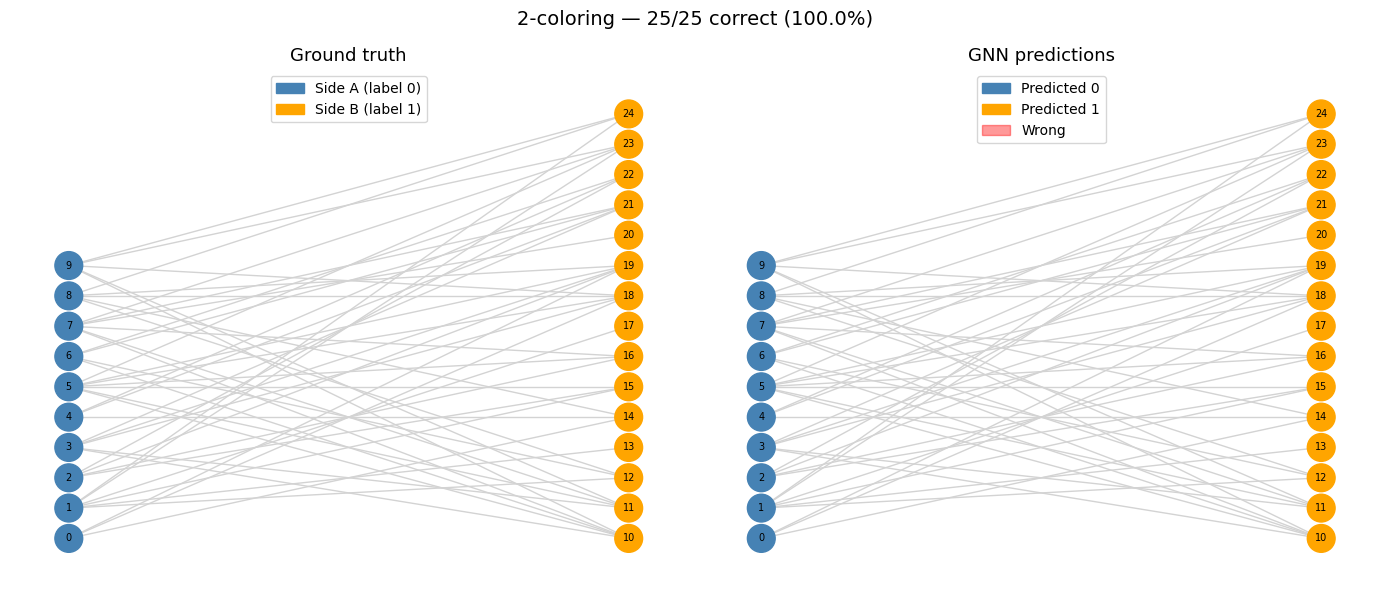

In [89]:
def visualise_coloring(model, data, n_per_side=20):
    model.eval()
    with torch.no_grad():
        logits = model(data)
        preds  = logits.argmax(dim=1)

    true  = data.y.numpy()
    preds = preds.numpy()

    # Rebuild networkx graph from edge_index for layout
    edge_index = data.edge_index.numpy()
    G = nx.Graph()
    G.add_nodes_from(range(data.num_nodes))
    G.add_edges_from(zip(edge_index[0], edge_index[1]))

    # Bipartite layout: side A on left, side B on right
    pos = {}
    side_A = [v for v in G.nodes() if true[v] == 0]
    side_B = [v for v in G.nodes() if true[v] == 1]
    for i, v in enumerate(side_A):
        pos[v] = (0, i)
    for i, v in enumerate(side_B):
        pos[v] = (2, i)

    # Node colors: green=correct, red=wrong
    node_colors = []
    for v in G.nodes():
        if preds[v] == true[v]:
            node_colors.append("mediumseagreen")
        else:
            node_colors.append("tomato")

    # Node shape encodes predicted class (circle=0, square=1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Left plot: ground truth ---
    ax = axes[0]
    ax.set_title("Ground truth", fontsize=13)
    colors_true = ["steelblue" if true[v] == 0 else "orange" 
                   for v in G.nodes()]
    nx.draw(G, pos, ax=ax, node_color=colors_true,
            node_size=400, with_labels=True, font_size=7,
            edge_color="lightgrey")
    # Legend
    from matplotlib.patches import Patch
    ax.legend(handles=[
        Patch(color="steelblue", label="Side A (label 0)"),
        Patch(color="orange",    label="Side B (label 1)")
    ], loc="upper center")

    # --- Right plot: predictions ---
    ax = axes[1]
    ax.set_title("GNN predictions", fontsize=13)
    colors_pred = ["steelblue" if preds[v] == 0 else "orange"
                   for v in G.nodes()]
    nx.draw(G, pos, ax=ax, node_color=colors_pred,
            node_size=400, with_labels=True, font_size=7,
            edge_color="lightgrey")

    # Mark wrong nodes with a red border
    wrong = [v for v in G.nodes() if preds[v] != true[v]]
    if wrong:
        nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=wrong,
                               node_color="red", node_size=500,
                               alpha=0.4)

    ax.legend(handles=[
        Patch(color="steelblue", label="Predicted 0"),
        Patch(color="orange",    label="Predicted 1"),
        Patch(color="red",       label="Wrong", alpha=0.4)
    ], loc="upper center")

    correct = (preds == true).sum()
    fig.suptitle(f"2-coloring — {correct}/{data.num_nodes} correct "
                 f"({100*correct/data.num_nodes:.1f}%)", fontsize=14)
    plt.tight_layout()
    plt.show()

# --- Run it ---
data_test = make_bipartite_graph()
visualise_coloring(model, data_test)

## Questions
1. What heppens if the parts of the bipartite graphs are set to be equal size? Why?

# Graph classification, Task 1: recognising 3-cycles

In this task we will use a GNN to try to detect the presence of triangles (i.e 3-cycles) in a graph. The GNN will use *random features*, meaning that the intended method of running the network is to initialise a vector sitting over each vertex with random numbers, then run those random numbers through the network.

## Generating data

For a graph on $n$ vertices, with edges drawn uniformly at random, it is likely that the graph contains a 3-cycle. We want a dataset evenly split between graphs which have 3-cycles, and graphs which do not. Instead of generating random graphs, we will instead generate random trees, and add in some 3-cycles.

In the following we are using some simple functions from the [NetworkX](https://networkx.org/) Python package, which implements a bunch of graph algorithms.

In [92]:
def create_triangled_tree(nnodes: int, ntriangles: int):
    """
    Create a tree on nnodes vertices, then add up to ntriangles to it (limited only by the
    number of addable triangles).
    """
    G = nx.random_labeled_tree(nnodes)

    if ntriangles > 0:
        # Add triangles by finding pairs of vertices at distance 2, and adding the missing edge.
        # Distances could be calculated much faster using a tree-specific algorithm rather than
        # the general Floyd-Warshall algorithm.
        dists = nx.floyd_warshall(G)
        dist2pairs = [(u, v) for u, v in itertools.combinations(G.nodes(), 2) if dists[u][v] == 2]
        for u, v in random.choices(dist2pairs, k=min(ntriangles, len(dist2pairs))):
            G.add_edge(u, v)

    return G

Running this function twice, we get an example of a tree, and another example with some 3-cycles added.

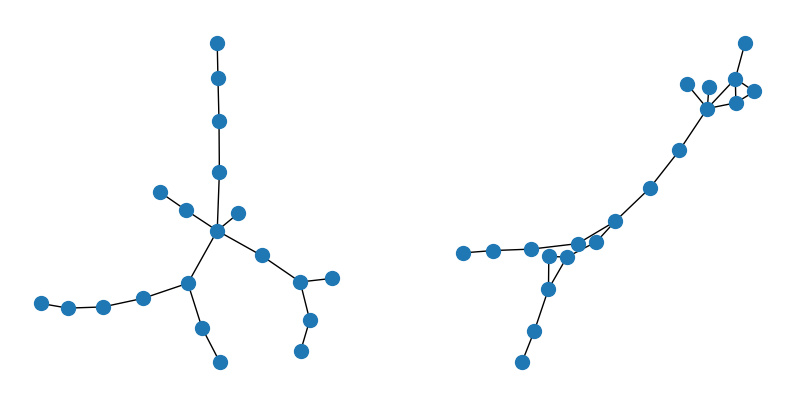

In [93]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
nx.draw(create_triangled_tree(20, 0), ax=axs[0], node_size=100)
nx.draw(create_triangled_tree(20, 3), ax=axs[1], node_size=100)
plt.show()

Next we need to put the data into a format that Torch Geometric likes. Luckily there is a conversion function from NetworkX graphs.

In [94]:
def generate_dataset(nnodes: int, ntriangles: int, ngraphs: int):
    """
    Generate a dataset, returning pair of ([torch_geometric.Data], torch.tensor). The first list
    returned holds the graphs in torch geometric format, and the second tensor of the same length
    contains a 0 if the graph has no triangles, and a 1 if the graph has triangles. The data is
    split evenly between having triangles and not having triangles.
    """
    istriangle = torch.zeros(ngraphs, dtype=torch.long)
    data = []
    for i in range(ngraphs):
        # Coin flip determines 0 => no triangles, 1 => triangles.
        coin = random.randint(0, 1)
        istriangle[i] = coin
        G = create_triangled_tree(nnodes, ntriangles * coin)
        data += [torch_geometric.utils.from_networkx(G)]

    return data, istriangle

generate_dataset(nnodes=10, ntriangles=3, ngraphs=10)

([Data(edge_index=[2, 22], num_nodes=10),
  Data(edge_index=[2, 24], num_nodes=10),
  Data(edge_index=[2, 22], num_nodes=10),
  Data(edge_index=[2, 18], num_nodes=10),
  Data(edge_index=[2, 24], num_nodes=10),
  Data(edge_index=[2, 18], num_nodes=10),
  Data(edge_index=[2, 22], num_nodes=10),
  Data(edge_index=[2, 18], num_nodes=10),
  Data(edge_index=[2, 18], num_nodes=10),
  Data(edge_index=[2, 18], num_nodes=10)],
 tensor([1, 1, 1, 0, 1, 0, 1, 0, 0, 0]))

## Define the model

As explained in the [PyTorch Geometric tutorial](https://pytorch-geometric.readthedocs.io/en/1.3.2/notes/create_gnn.html), the `torch_geometric.nn.MessagePassing` base class can set up a lot of the message-passing network for us: we only need to define an initialiser, a `message()` function (sends information from vertices to other vertices), an `aggr` method for aggregation of that information (`add`, `mean`, `max`, ...), and an `update()` function specifying what to do with that aggregated data. For us, both the `message()` and `update()` functions are the identity, and can be omitted from the class definition.

In [95]:
class GNNLayer(torch_geometric.nn.MessagePassing):
    def __init__(self, in_features, out_features):
        super().__init__(aggr='add')

        self.linear = nn.Linear(in_features, out_features) # Linear, not affine!

    def forward(self, x, edge_index):
        # x has shape [number_of_nodes, in_channels]
        # edge_index has shape [2, number_of_edges]

        # Add self-loops to the adjacency matrix.
        edge_index, _ = torch_geometric.utils.add_self_loops(edge_index, num_nodes=x.shape[0])

        # Transform features using the learnable parameters
        x = self.linear(x)

        # Propagate messages to other vertices.
        return self.propagate(edge_index, size=(x.shape[0], x.shape[0]), x=x)


# An example of how to run this layer: let's take a random graph from our dataset.
graph = generate_dataset(nnodes=10, ntriangles=3, ngraphs=10)[0][0]

# graph.edge_index has shape [2, number_of_edges] and is an adjacency list. This gets
# passed to the GNN layer, along with a data tensor of shape [number_of_nodes, number_of_features].
# Note: the edge index defines the number of vertices in the graph only if you already know the graph
# is connected.
#
# Here we are simulating a layer which maps a 4-feature vector sitting over each vertex to a 3-feature
# vector sitting over each vertex.
# Input features: shape [# vertices, # features]
GNNLayer(4, 3)(torch.zeros(10, 4), graph.edge_index)

tensor([[-0.1427,  0.0641,  0.7919],
        [-0.1427,  0.0641,  0.7919],
        [-0.1427,  0.0641,  0.7919],
        [-0.4993,  0.2245,  2.7715],
        [-0.2853,  0.1283,  1.5837],
        [-0.2140,  0.0962,  1.1878],
        [-0.1427,  0.0641,  0.7919],
        [-0.1427,  0.0641,  0.7919],
        [-0.1427,  0.0641,  0.7919],
        [-0.1427,  0.0641,  0.7919]], grad_fn=<ScatterAddBackward0>)

In [96]:
# Let's fix some parameter sizes from here
NODES = 20
FEATURES = 5
GRAPHS = 1000

graphs, istriangle = generate_dataset(nnodes=NODES, ntriangles=3, ngraphs=GRAPHS)

In [97]:
class GNNModel(nn.Module):
    def __init__(self):
        super().__init__()

        # A 3-deep layer of GNN stuff.
        self.gnn_layers = nn.ModuleList([
            GNNLayer(FEATURES, FEATURES),
            GNNLayer(FEATURES, FEATURES),
            GNNLayer(FEATURES, FEATURES),
        ])

        # A fully-connected classification layer. Since we want a binary classifier (triangle vs
        # no triangle), the target dimension is 2.
        #
        # Note: this architecture is assuming that the number of nodes in every input graph is the same!
        self.fully_connected_layer = nn.Linear(NODES * FEATURES, 2)

    def forward(self, x, edge_index):
        for layer in self.gnn_layers:
            x = layer(x, edge_index)
            x = nn.functional.relu(x)

        x = torch.reshape(x, (-1, FEATURES * NODES))
        x = self.fully_connected_layer(x)
        return x


GNNModel()(torch.zeros((NODES, FEATURES)), graphs[0].edge_index)

tensor([[0.0194, 0.2336]], grad_fn=<AddmmBackward0>)

## Training

Training works the exact same way for a GNN as it does for any other neural network. There is one difference with our setting compared to most GNNs: our graphs do not have any intrinsic vertex or edge features (beyond those which are implied just based on the graph structure, degree and so on). We are actually going to use random features: each time we want to run a graph through the network, we initialise the vectors sitting over the vertices with numbers taken uniformly at random from $[0, 1]$.

749 chosen for training


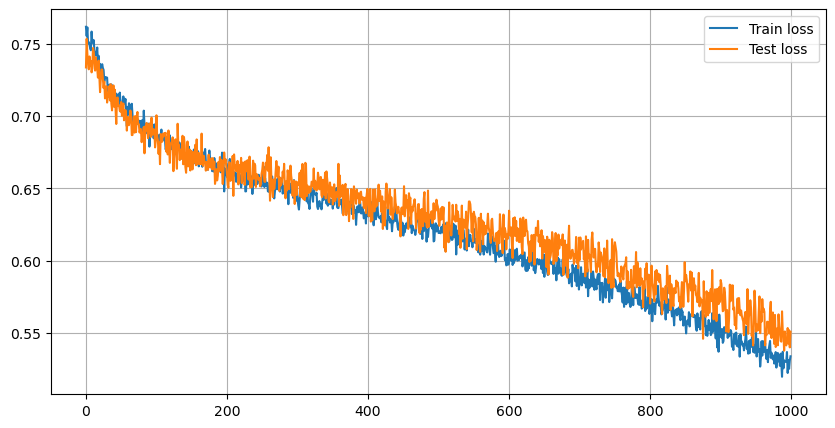

In [99]:
EPOCHS = 1000

# Create a fresh model.
model = GNNModel()

# Split the training and testing data. Each of train_mask and test_mask are vectors of
# booleans, which index like you might expect: [1, 2, 3][True, False, True] == [1, 3].
train_mask = torch.rand(GRAPHS) < 0.75
test_mask = ~train_mask
print(int(train_mask.sum()), "chosen for training")

# Create a training batch and testing batch. This will help for batching data together
# in the network.
train_batch = torch_geometric.data.Batch.from_data_list([graph for i, graph in enumerate(graphs) if train_mask[i]])
test_batch = torch_geometric.data.Batch.from_data_list([graph for i, graph in enumerate(graphs) if test_mask[i]])

# Set up our usual friends, the loss function and gradient descent function.
loss_function = nn.CrossEntropyLoss()
optimiser = torch.optim.SGD(model.parameters(), lr=0.001)

# Tensors to record the training loss and testing loss at each epoch.
train_loss = torch.zeros(EPOCHS)
test_loss = torch.zeros(EPOCHS)

for epoch in range(EPOCHS):
    # Zero gradient, and initialise a new set of random features to use for all graphs.
    optimiser.zero_grad()

    # Create random features, send them through the network. Let's do this 10 times with random features
    # before each gradient descent step.
    repeats = 10
    loss = torch.zeros(1)
    for i in range(repeats):
        features = torch.rand(train_batch.num_graphs * NODES, FEATURES)
        result = model(features, train_batch.edge_index)
        loss += loss_function(result, istriangle[train_mask])

    loss /= repeats
    loss.backward()
    optimiser.step()

    with torch.no_grad():
        features = torch.rand(train_batch.num_graphs * NODES, FEATURES)
        train_loss[epoch] = loss_function(model(features, train_batch.edge_index), istriangle[train_mask])

        features = torch.rand(test_batch.num_graphs * NODES, FEATURES)
        test_loss[epoch] = loss_function(model(features, test_batch.edge_index), istriangle[test_mask])


fig, ax = plt.subplots(figsize=(10, 5))
ax.grid()
ax.plot(train_loss, label='Train loss')
ax.plot(test_loss, label='Test loss')
ax.legend()
plt.show()

## Evaluate the effectiveness of the network

As usual, the loss function is somewhat difficult to interpret, and does not necessarily reflect the accuracy of the resulting network. As in the Möbius eaxmple, we will take the test batch (not including the training data: here we are interested in how well the network performs on data it has never seen before) and create a list of (actual, predicted) pairs. 0 means "no triangle", and 1 means "triangle".

In [100]:
with torch.no_grad():
    features = torch.rand(test_batch.num_graphs * NODES, FEATURES)
    result = model(features, test_batch.edge_index)
    results = pd.DataFrame.from_dict({
        'actual': istriangle[test_mask],
        'predicted': torch.max(result, dim=-1).indices,
    })

results

,actual,predicted
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
...,...,...
246,0,0
247,1,1
248,0,0
249,0,1


In [101]:
counts = results.pivot_table(index='actual', columns='predicted', aggfunc=len, fill_value=0)
(counts / counts.sum().sum()).round(2)

predicted,0,1
actual,,
0,0.26,0.21
1,0.05,0.48


## Discussion questions

**Network depth:** Does network depth have an effect on whether this classification problem is successful?

**Dataset generation:** The graph generation strategy shown above may be too rigid: for example the neural network can predict the right answer just by counting the number of edges in the graph (if the number of edges is one fewer than the number of vertices, we have a tree, and in this dataset, any non-tree has triangles). Come up with some methods of generating some more robust data for this problem. This leads into the next problem...


**Pooling:** A major deficiency of this network is the fully-connected layer at the end, which assumes that there will always be the same number of vertices in every graph. A better strategy would be to perform max-pooling across all vertices so that the summary of a graph is a single feature vector; then a fully-connected layer following that can treat every graph uniformly. Figure out how to do this using PyTorch Geometric (I ran out of time trying to figure out how to do this, and also make batching work).

**More properties:** What are some other simple properties of graphs that fit into this framework? Try them out!

**Some suggestions:**
* Does the graph contain a 4-cycle? (harder for 1-WL GNNs)
* Is the graph bipartite? (equivalent to no odd cycle — a nice negative result: GNNs can learn this)
* Does the graph contain a Hamiltonian path? (NP-hard in general)


* Graph isomorphism classes of small graphs. Generate all non-isomorphic graphs on n=6 or 7 nodes (there are 156 on 7 nodes). Label each by its isomorphism class. A standard GNN will fail to distinguish some pairs — precisely those that the [WL](https://en.wikipedia.org/wiki/Weisfeiler_Leman_graph_isomorphism_test) test cannot distinguish.
* Detecting planarity. Using NetworkX's is_planar(). Question: does GNN "learn"  [Kuratowski's theorem](https://en.wikipedia.org/wiki/Kuratowski%27s_theorem) or is pattern-matching.
*  Graph genus / topological invariants.  For the more algebraically inclined: generate graphs and label them by the genus of the surface they embed in (0 = planar, 1 = torus, etc.). 